# Set environment

In [51]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys

### keras
from keras            import Sequential, models, layers
from keras.utils      import to_categorical
from keras.optimizers import SGD, Adam

### import flowImg
py_path = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image"
sys.path.insert(0, py_path)
from flowImg import *

### sklearn
from sklearn.metrics import roc_curve, auc, accuracy_score

### plot
import matplotlib.pyplot as plt
plt.style.use("seaborn-whitegrid")

### global const
SEED    = 123
DAT_DIR = "/data/clintko/flow_EQAPOL_normal/pipe01"
FP_FIG  = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image/fig"

In [2]:
import tensorflow as tf
from keras import backend as k
### suppress warning
### ref: https://stackoverflow.com/questions/48608776/how-to-suppress-tensorflow-warning-displayed-in-result
tf.logging.set_verbosity(tf.logging.ERROR)

### restrict the memory usage of tensorflow
config = tf.ConfigProto()
config.gpu_options.allow_growth = True
k.tensorflow_backend.set_session(tf.Session(config=config))

### ref: https://machinelearningmastery.com/reproducible-results-neural-networks-keras/
from numpy.random import seed
#seed(SEED)
from tensorflow import set_random_seed
#set_random_seed(SEED)

In [23]:
%matplotlib inline

# Load Data

In [33]:
fname = "wrap05_img_1e4_var01.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")
wrap_tsne = pickle.load(file)
file.close()

# Load Model

In [6]:
models.model_from_yaml

<function keras.models.model_from_yaml>

In [7]:
# load history
fname      = os.path.join(DAT_DIR, "model_vgg16_lr5e6_bs10_noBNorm_history.P")
file       = open(fname, "rb")
history    = pickle.load(file)
file.close()

# load YAML and create model
fname      = os.path.join(DAT_DIR, "model_vgg16_lr5e6_bs10_noBNorm.yaml")
yaml_file  = open(fname, 'r')
model_yaml = yaml_file.read()
model      = models.model_from_yaml(model_yaml)
yaml_file.close()

# load weights into new model
fname      = os.path.join(DAT_DIR, "model_vgg16_lr5e6_bs10_noBNorm.h5")
model.load_weights(fname)
print("Loaded model from disk")

Loaded model from disk


check the results

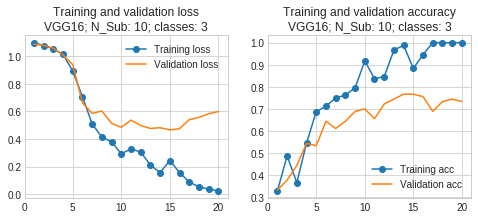

In [9]:
n_class = 3
title   = "\nVGG16; N_Sub: 10; classes: " + str(n_class)

### extract the training / validation loss from fitting history
acc      = history['acc']
val_acc  = history['val_acc']
loss     = history['loss']
val_loss = history['val_loss']
epochs = range(1, len(acc) + 1)

### visualize the training / validation loss
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))
ax = axes[0]
ax.plot(epochs, loss,     'o-', label='Training loss')
ax.plot(epochs, val_loss, '-',  label='Validation loss')
ax.set_title('Training and validation loss' + title)
ax.legend()

ax = axes[1]
ax.plot(epochs, acc,      'o-', label='Training acc')
ax.plot(epochs, val_acc,  '-',  label='Validation acc')
ax.set_title('Training and validation accuracy' + title)
ax.legend()

plt.show()

### Recall the model structure

In [10]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 128, 128, 64)      8128      
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 128, 128, 64)      36928     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 64, 64, 64)        0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 64, 64, 128)       73856     
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 64, 64, 128)       147584    
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 32, 32, 128)       0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 32, 32, 256)       295168    
__________

# Visualization

In [14]:
from keras import activations

from vis.input_modifiers import Jitter
from vis.utils import utils
from vis.visualization import visualize_activation

In [13]:
### get the last layer
layer_name = "dense_3"
layer_idx = utils.find_layer_idx(model, layer_name)

### switch the layer from softmax into linear
model.layers[layer_idx].activation = activations.linear
model = utils.apply_modifications(model)

/local_data/env-py3/lib/python3.6/site-packages/keras/models.py:252: UserWarning: No training configuration found in save file: the model was *not* compiled. Compile it manually.
  warnings.warn('No training configuration found in save file: '


In [16]:
print(layer_name, "|", layer_idx)

dense_3 | 21


# Activation Map

In [62]:
wrap_tsne.label[0]

0

In [56]:
img = wrap_tsne.img[0].reshape(128, 128, 14)
img = np.expand_dims(img, axis = 0)
img.shape

(1, 128, 128, 14)

In [57]:
layer_outputs    = [layer.output for layer in model.layers if 'conv' in layer.name]
activation_model = models.Model(inputs=model.input, outputs=layer_outputs)
intermediate_activations = activation_model.predict(img)

print(type(intermediate_activations))
print(len(intermediate_activations))

first_layer_activation = intermediate_activations[0]
print(type(first_layer_activation))
print(first_layer_activation.shape)

<class 'list'>
13
<class 'numpy.ndarray'>
(1, 128, 128, 64)


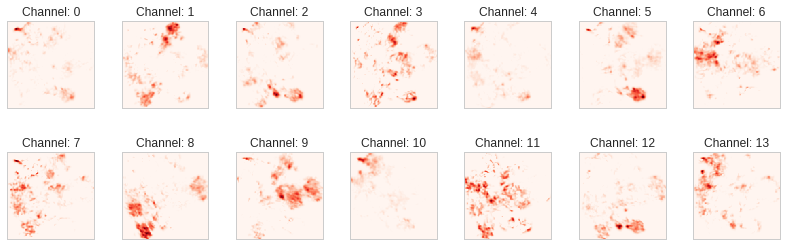

In [61]:
fig, axes = plt.subplots(ncols=7, nrows=2, figsize=(14, 4))
plt.subplots_adjust(hspace = 0.5)
axes = axes.ravel()

img = img[0]

for idx, ax in enumerate(axes):
    ax.imshow(img_map[:, :, idx], cmap= "Reds")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title("Channel: " + str(idx))
    
#fname = os.path.join(FP_FIG, "ActMap_LayerFirst.png")    
#plt.savefig(fname, dpi = 300)
plt.show()

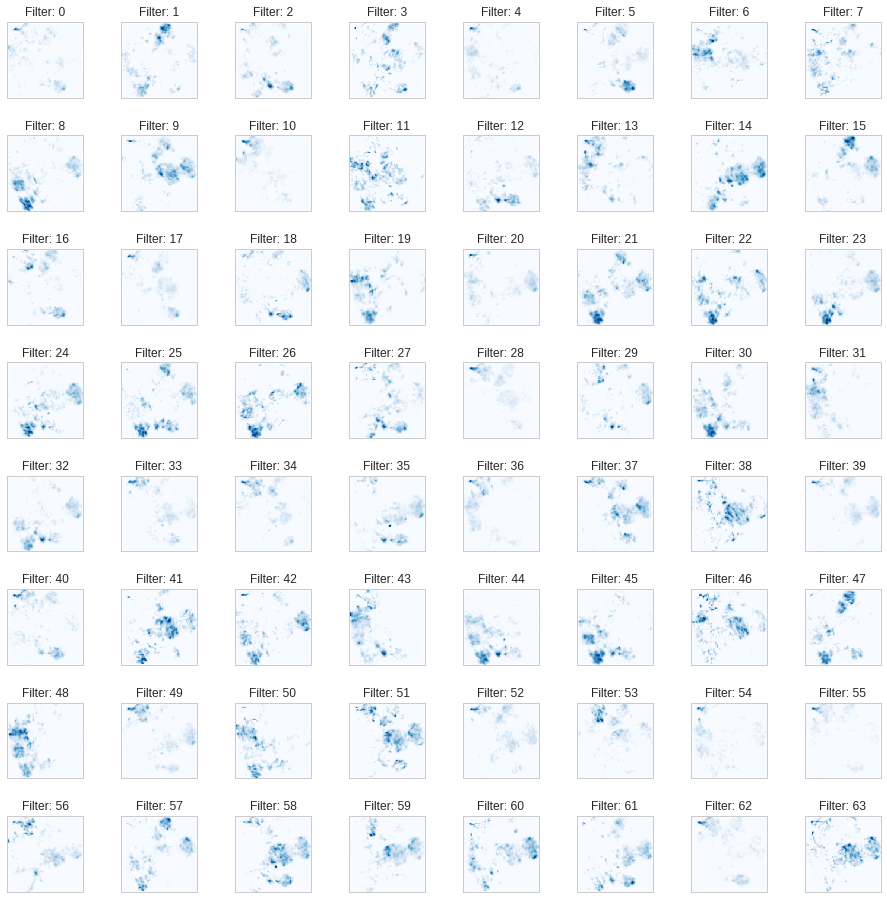

In [58]:
fig, axes = plt.subplots(ncols=8, nrows=8, figsize=(16, 16))
plt.subplots_adjust(hspace = 0.5)
axes = axes.ravel()

img_map = first_layer_activation[0]

for idx, ax in enumerate(axes):
    ax.imshow(img_map[:, :, idx], cmap= "Blues")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title("Filter: " + str(idx))
    
fname = os.path.join(FP_FIG, "ActMap_LayerFirst.png")    
plt.savefig(fname, dpi = 300)
plt.show()

# Activation Maximization Map

In [21]:
# 20 is the imagenet category for 'ouzel'
# Jitter 16 pixels along all dimensions to during the optimization process.
filter_idx = 0
img_fidx0 = visualize_activation(model, layer_idx, filter_indices=filter_idx, max_iter=500, input_modifiers=[Jitter(16)])

filter_idx = 1
img_fidx1 = visualize_activation(model, layer_idx, filter_indices=filter_idx, max_iter=500, input_modifiers=[Jitter(16)])

filter_idx = 2
img_fidx2 = visualize_activation(model, layer_idx, filter_indices=filter_idx, max_iter=500, input_modifiers=[Jitter(16)])

In [59]:
for img in [img_fidx0, img_fidx1, img_fidx2]:
    print(img.shape)

(128, 128, 14)
(128, 128, 14)
(128, 128, 14)


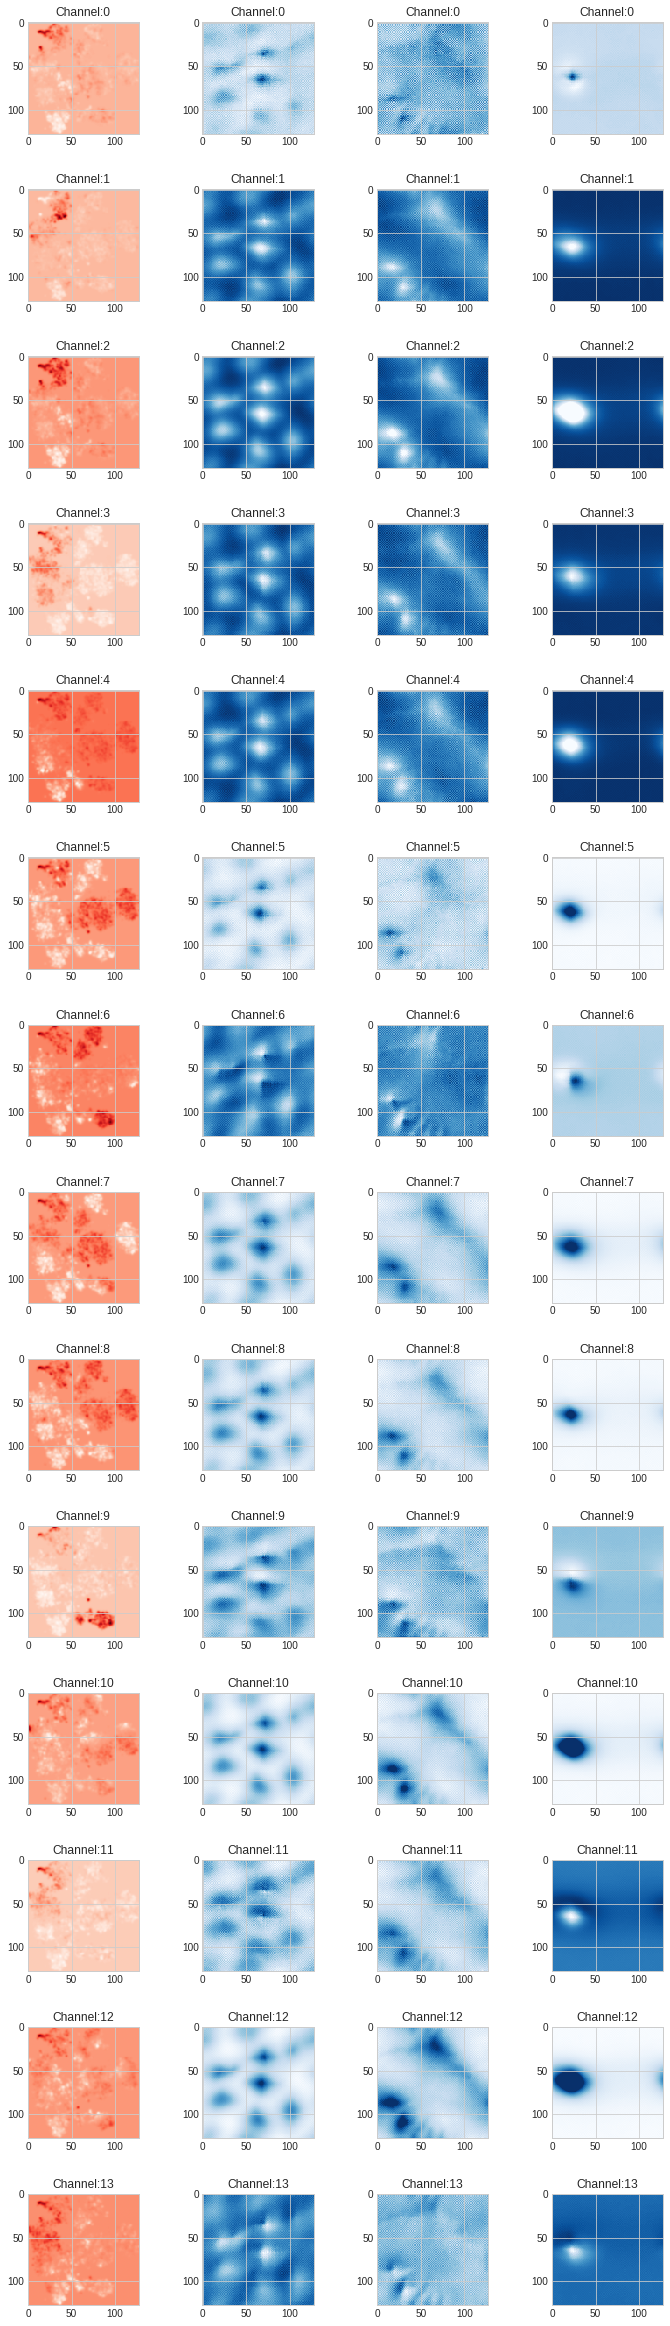

In [60]:
fig, axes = plt.subplots(ncols=4, nrows=14, figsize=(12, 42))
plt.subplots_adjust(hspace = 0.5)

cur_axes = axes[:, 0]
img = wrap_tsne.img[0].reshape(128, 128, 14)
for idx, ax in enumerate(cur_axes):
    ax.imshow(img[:, :, idx], cmap = "Reds")
    ax.set_title("Channel:" + str(idx))

cur_axes = axes[:, 1]
img = img_fidx0
for idx, ax in enumerate(cur_axes):
    ax.imshow(img[:, :, idx], cmap = "Blues")
    ax.set_title("Channel:" + str(idx))

cur_axes = axes[:, 2]    
img = img_fidx1
for idx, ax in enumerate(cur_axes):
    ax.imshow(img[:, :, idx], cmap = "Blues")
    ax.set_title("Channel:" + str(idx))

cur_axes = axes[:, 3]    
img = img_fidx2
for idx, ax in enumerate(cur_axes):
    ax.imshow(img[:, :, idx], cmap = "Blues")
    ax.set_title("Channel:" + str(idx))
    
fname = os.path.join(FP_FIG, "ActMaxMap_LayerLast.png")    
plt.savefig(fname, dpi = 300)

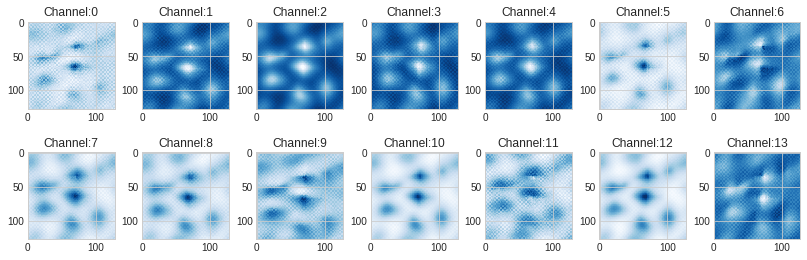

In [29]:
fig, axes = plt.subplots(ncols=7, nrows=2, figsize=(14, 4))
plt.subplots_adjust(hspace = 0.5)
axes = axes.ravel()

img = img_fidx0
for idx, ax in enumerate(axes):
    ax.imshow(img[:, :, idx], cmap = "Blues")
    ax.set_title("Channel:" + str(idx))

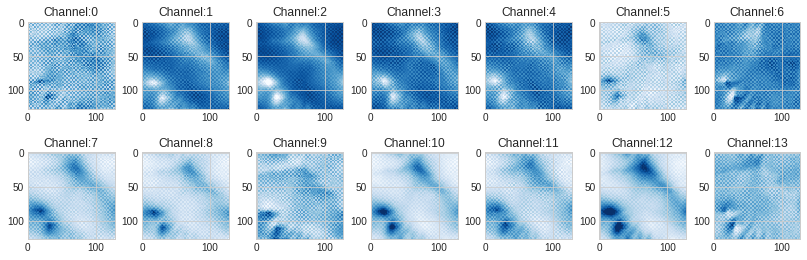

In [30]:
fig, axes = plt.subplots(ncols=7, nrows=2, figsize=(14, 4))
plt.subplots_adjust(hspace = 0.5)
axes = axes.ravel()

img = img_fidx1
for idx, ax in enumerate(axes):
    ax.imshow(img[:, :, idx], cmap = "Blues")
    ax.set_title("Channel:" + str(idx))

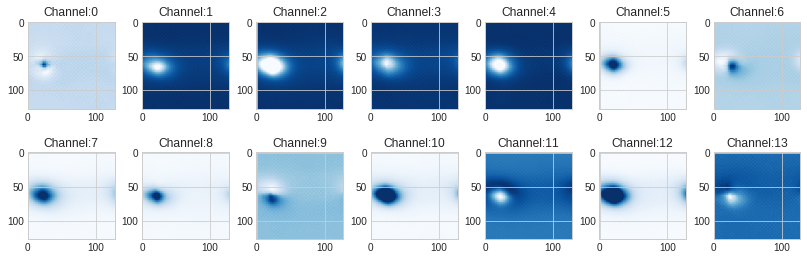

In [31]:
fig, axes = plt.subplots(ncols=7, nrows=2, figsize=(14, 4))
plt.subplots_adjust(hspace = 0.5)
axes = axes.ravel()

img = img_fidx2
for idx, ax in enumerate(axes):
    ax.imshow(img[:, :, idx], cmap = "Blues")
    ax.set_title("Channel:" + str(idx))